<a href="https://colab.research.google.com/github/Yogen4/Workshop.ai/blob/main/Week7(Tutorial7)AI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
data_dir = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train"   # CHANGE THIS
img_size = 32
images = []

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((img_size, img_size))
                images.append(np.array(img))
            except:
                pass

print("Total images loaded:", len(images))

Total images loaded: 6845


In [ ]:
# Ensure correct type
if isinstance(images, list):
    images = np.array(images)

print("Images type:", type(images))
print("Images shape:", images.shape)

# Now split
x_train, x_test = train_test_split(images, test_size=0.2, random_state=42)

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Images type: <class 'numpy.ndarray'>
Images shape: (6845, 32, 32)
Train: (5476, 32, 32)
Test: (1369, 32, 32)


In [ ]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

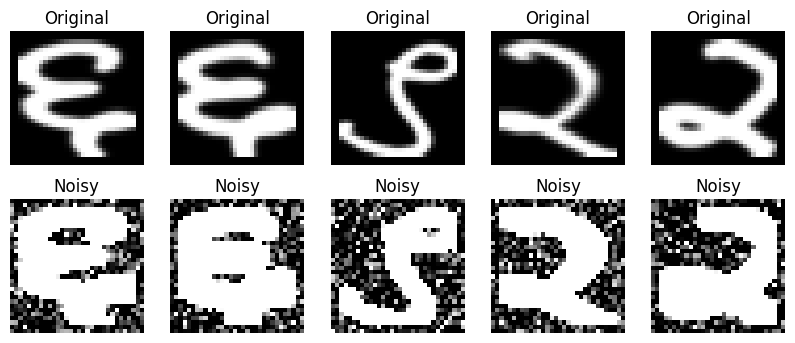

In [ ]:
n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # original
    plt.subplot(2, n, i+1)
    plt.imshow(x_train[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # noisy
    plt.subplot(2, n, i+1+n)
    plt.imshow(x_train_noisy[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.show()

In [ ]:
input_img = Input(shape=(img_size, img_size, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 38s 811ms/step - loss: -964.9935 - val_loss: -1055.6755
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 39s 777ms/step - loss: -1048.0155 - val_loss: -1055.6755
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 784ms/step - loss: -1048.0157 - val_loss: -1055.6755
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 33s 767ms/step - loss: -1048.0156 - val_loss: -1055.6755
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 33s 767ms/step - loss: -1048.0157 - val_loss: -1055.6755
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 765ms/step - loss: -1048.0154 - val_loss: -1055.6755
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 764ms/step - loss: -1048.0155 - val_loss: -1055.6755
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 33s 760ms/step - loss: -1048.0157 - val_loss: -1055.6755
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 769ms/step - loss: -1048.0155 - val_loss: -1055.6755
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 42s 783ms/step - loss: -1048.0157 - val_loss: -1055.6755


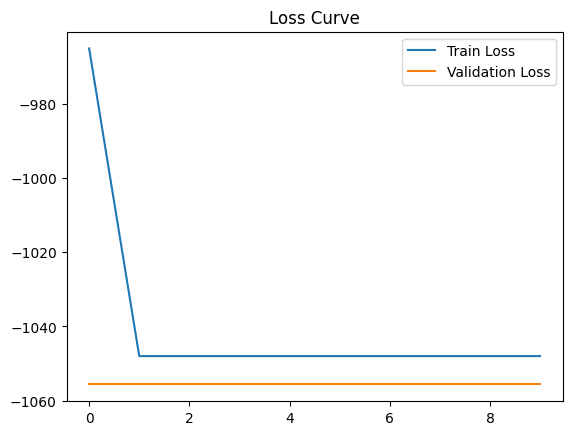

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [ ]:
denoised = autoencoder.predict(x_test_noisy)


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step


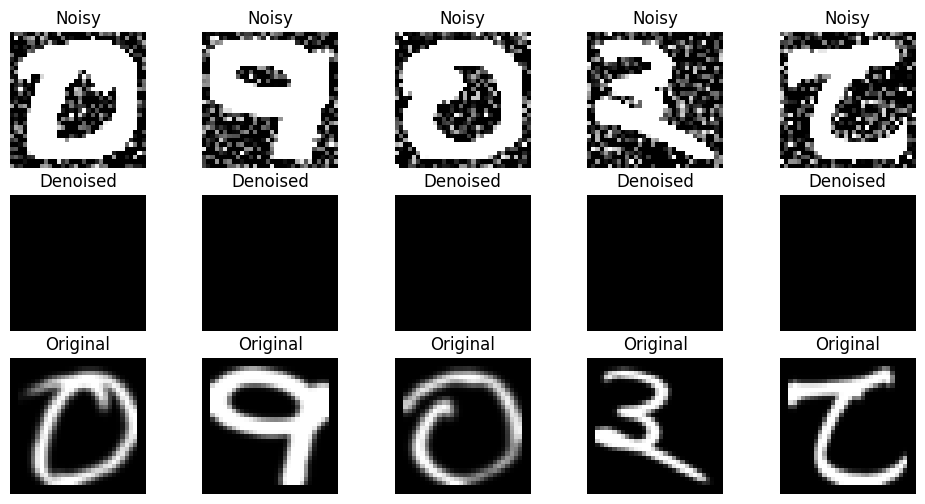

In [ ]:
n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    # noisy
    plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # denoised
    plt.subplot(3, n, i+1+n)
    plt.imshow(denoised[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # original
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].reshape(img_size, img_size), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.show()

## Observations

1.  **Data Loading and Preprocessing**: Images were successfully loaded, resized to 32x32 pixels, converted to grayscale, and split into training and testing sets. Noise was added to create noisy versions of the images.
2.  **Autoencoder Model**: A convolutional autoencoder model was defined with an encoder-decoder architecture, compiled with `Adam` optimizer and `binary_crossentropy` loss.
3.  **Training Issues**: During training, the `binary_crossentropy` loss became unusually large and negative, remaining flat across epochs. This indicates a significant problem, as `binary_crossentropy` should typically yield non-negative values and show a decreasing trend if the model is learning.
4.  **Denoising Performance**: As a result of the training issue, the autoencoder failed to denoise the images effectively. The predicted denoised images were almost entirely white (or saturated), indicating that the model did not learn to reconstruct the original images from their noisy counterparts. This suggests a potential issue with data scaling (e.g., pixel values not normalized to 0-1 range) before feeding into the model that uses `sigmoid` activation in the output layer and `binary_crossentropy` loss.